In [1]:
from pathlib import Path

try:
  import google.colab
  IN_COLAB = True

  # Cell 1 (Colab only - skip locally)
  !git clone https://github.com/RealAshrafAhmed/waterloo-slt-reading-group.git /content/repo
  %cd /content/repo
  !pip install uv && uv sync --all-packages
  
  # Cell 2 (both environments)
  from colab_extensions.env import setup
  env = setup()
  ROOT, DATA, OUTPUTS = env["ROOT"], env["DATA"], env["OUTPUTS"]
except ImportError:
  IN_COLAB = False
  ROOT = Path.cwd().parents[1]
  basedir = f"{ROOT}/outputs/mixture/poisson2d"
  datadir = f"{basedir}/data"
  outputdir = Path(f"{basedir}/posterior")


if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior


In [2]:
# Must be FIRST - before any other imports
import os
os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="

import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
  if Path("/content/drive").exists():
    print("Nothing to initialize, driver is already mounted!")
  else:
    from google.colab import drive
    drive.mount('/content/drive')
    colab_dir = f"/content/drive/MyDrive/colab"
    if colab_dir not in sys.path:
      sys.path.insert(0, colab_dir)
    from colab_setup import init
    paths = init("singular-learning-theory")
    print("Installing tex")
    !apt-get install texlive-fonts-recommended texlive-latex-extra texlive-pictures dvipng

  datadir = "/content/drive/MyDrive/colab/outputs/singular-learning-theory/mixtures/poisson2d"
else:
  from pathlib import Path
  paths = {'repo': Path.cwd(), 'output': Path.cwd() / 'outputs'}
  paths['output'].mkdir(exist_ok=True)
  print("📍 Running locally")
  from pathlib import Path

  ROOT = Path.cwd().parents[1]
  basedir = f"{ROOT}/outputs/mixture/poisson2d"
  datadir = f"{basedir}/data"
  outputdir = Path(f"{basedir}/posterior")


if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

📍 Running locally
Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior


In [3]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,15,5,0.75,0.25
2,singular1,15,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [4]:
def find_truth_by_dsid(dsid: str):
    dgp = dgps.query(f"dsid=='{dsid}'")
    truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
    return truth

In [5]:
import pytensor
import pymc as pm
import numpy as np
from tqdm.notebook import tqdm
import arviz as az


n_components = 2
n_trials = 100

regimes = [50, 250, 5000]

n_draws = 2000
n_tune = 10000
posterior_samples = {}

for dsid in tqdm(dgps["dsid"].unique(), desc=f"class "):
  posterior_samples[dsid] = {}
  for regime in tqdm(regimes, desc=f"dsid={dsid}, regime "):
    posterior_data_file = Path(f"{outputdir}/posterior-{dsid}-{regime}.nc")
    if posterior_data_file.exists(): # check if this data has already been generated
        idata = az.from_netcdf(posterior_data_file)
        print(f"Loaded posterior data from {posterior_data_file}!")
    else:
      dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
      X = dataset.iloc[:, 0].to_numpy()
      # Mixture of 2 Poisson variables
      with pm.Model() as model:
        weights = pm.Dirichlet("weights", a=np.array([1, 1]))  # 2 mixture weights
        
        mus = [pm.Gamma(f"m{i}", alpha=0.001, beta=0.001) for i in range(n_components)]
        components = [pm.Poisson.dist(mu=mu) for mu in mus]
      
        like = pm.Mixture("like", w=weights, comp_dists=components, observed=X)
        idata = pm.sample(nuts_sampler="numpyro",
                          draws=n_draws,
                          chains=4,
                          max_treedepth=50,
                          tune=n_tune,
                          target_accept=0.999)  # or "blackjax"
        # posterior_samples[dsid][regime] = idata
        idata.to_netcdf(posterior_data_file)
        print(f"File {posterior_data_file} created!.")
        
    posterior_samples[dsid][regime]=idata

class :   0%|          | 0/4 [00:00<?, ?it/s]

dsid=regular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-regular-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-regular-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-regular-5000.nc!


dsid=e-singular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-e-singular-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-e-singular-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-e-singular-5000.nc!


dsid=singular1, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular1-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular1-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular1-5000.nc!


dsid=singular2, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular2-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular2-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular2-5000.nc!


In [6]:
def chain_diag(dsid="singular1", regime=5000):
  az.plot_trace(posterior_samples[dsid][regime], combined=True)

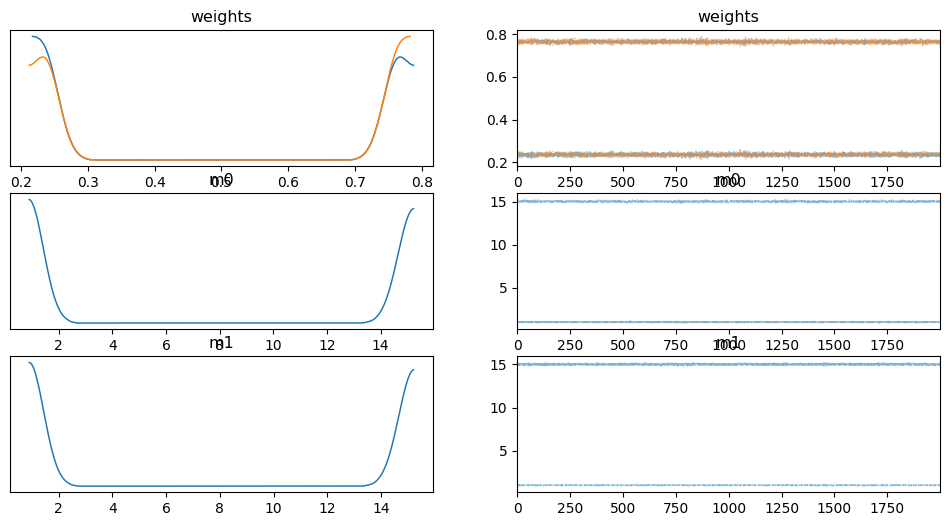

In [7]:
chain_diag("regular", 5000)

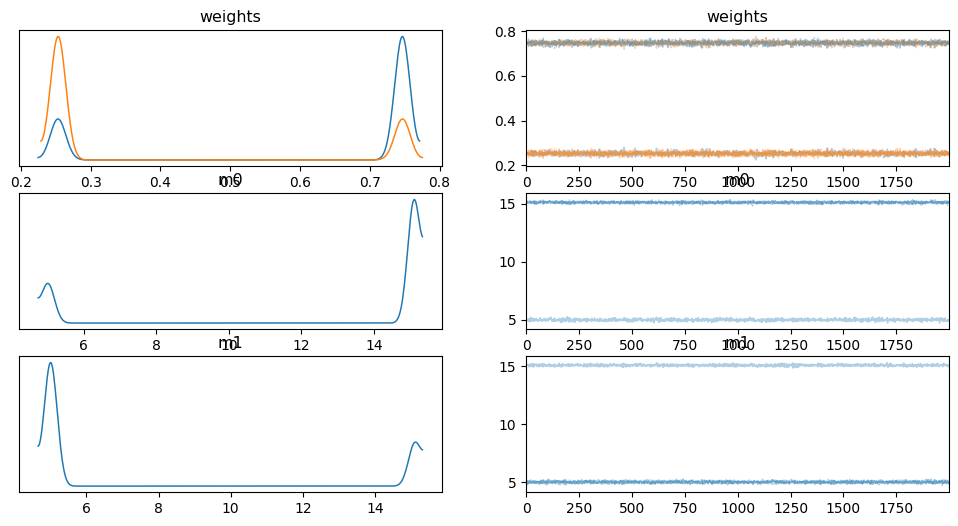

In [8]:
chain_diag("e-singular", 5000)

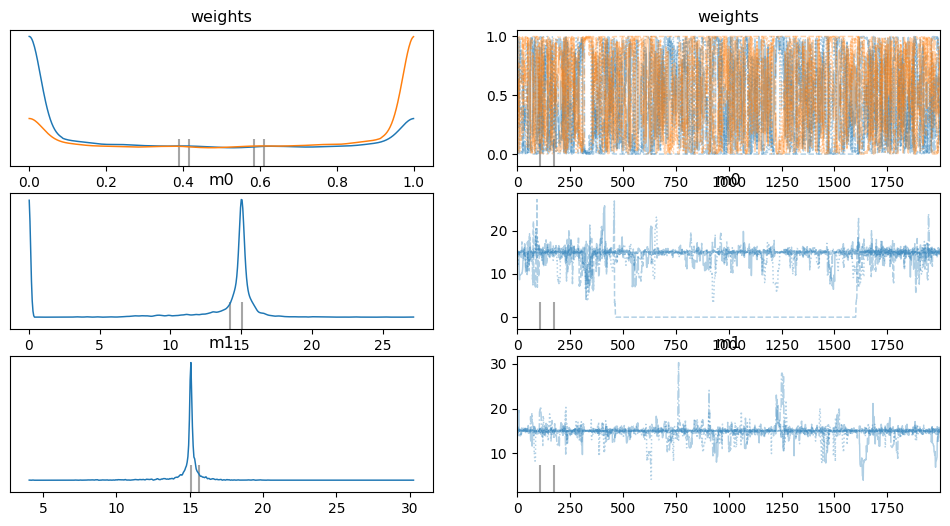

In [9]:
chain_diag("singular1", 5000)

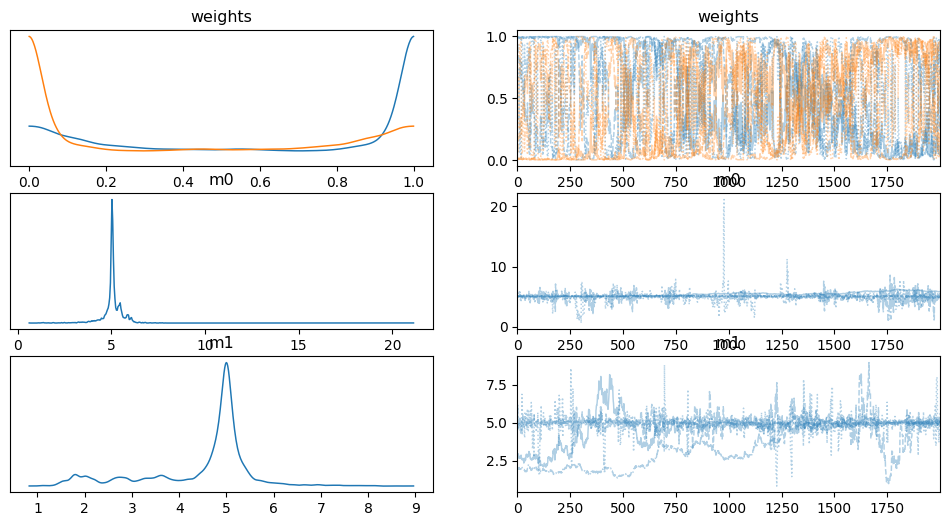

In [10]:
chain_diag("singular2", 5000)

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3d(dsid="singular1", regime=5000):
  idata = posterior_samples[dsid][regime]
  w = idata.posterior["weights"][1,:,0]
  p0 = idata.posterior["m0"][1,:]
  p1 = idata.posterior["m1"][1,:]
  
  fig = plt.figure(figsize=(12, 10))  # width, height in inches
  ax = fig.add_subplot(111, projection='3d')
  
  n_chains = idata.posterior.dims["chain"]
  n_draws = idata.posterior.dims["draw"]
  markers = ['o', '^', '.', '+']
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain,:,0]
    p0 = idata.posterior["m0"][chain,:]
    p1 = idata.posterior["m1"][chain,:]
    ax.scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)


/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_52674/1418084222.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain in range(idata.posterior.dims["chain"]):
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_52674/1418084222.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims["chain"]


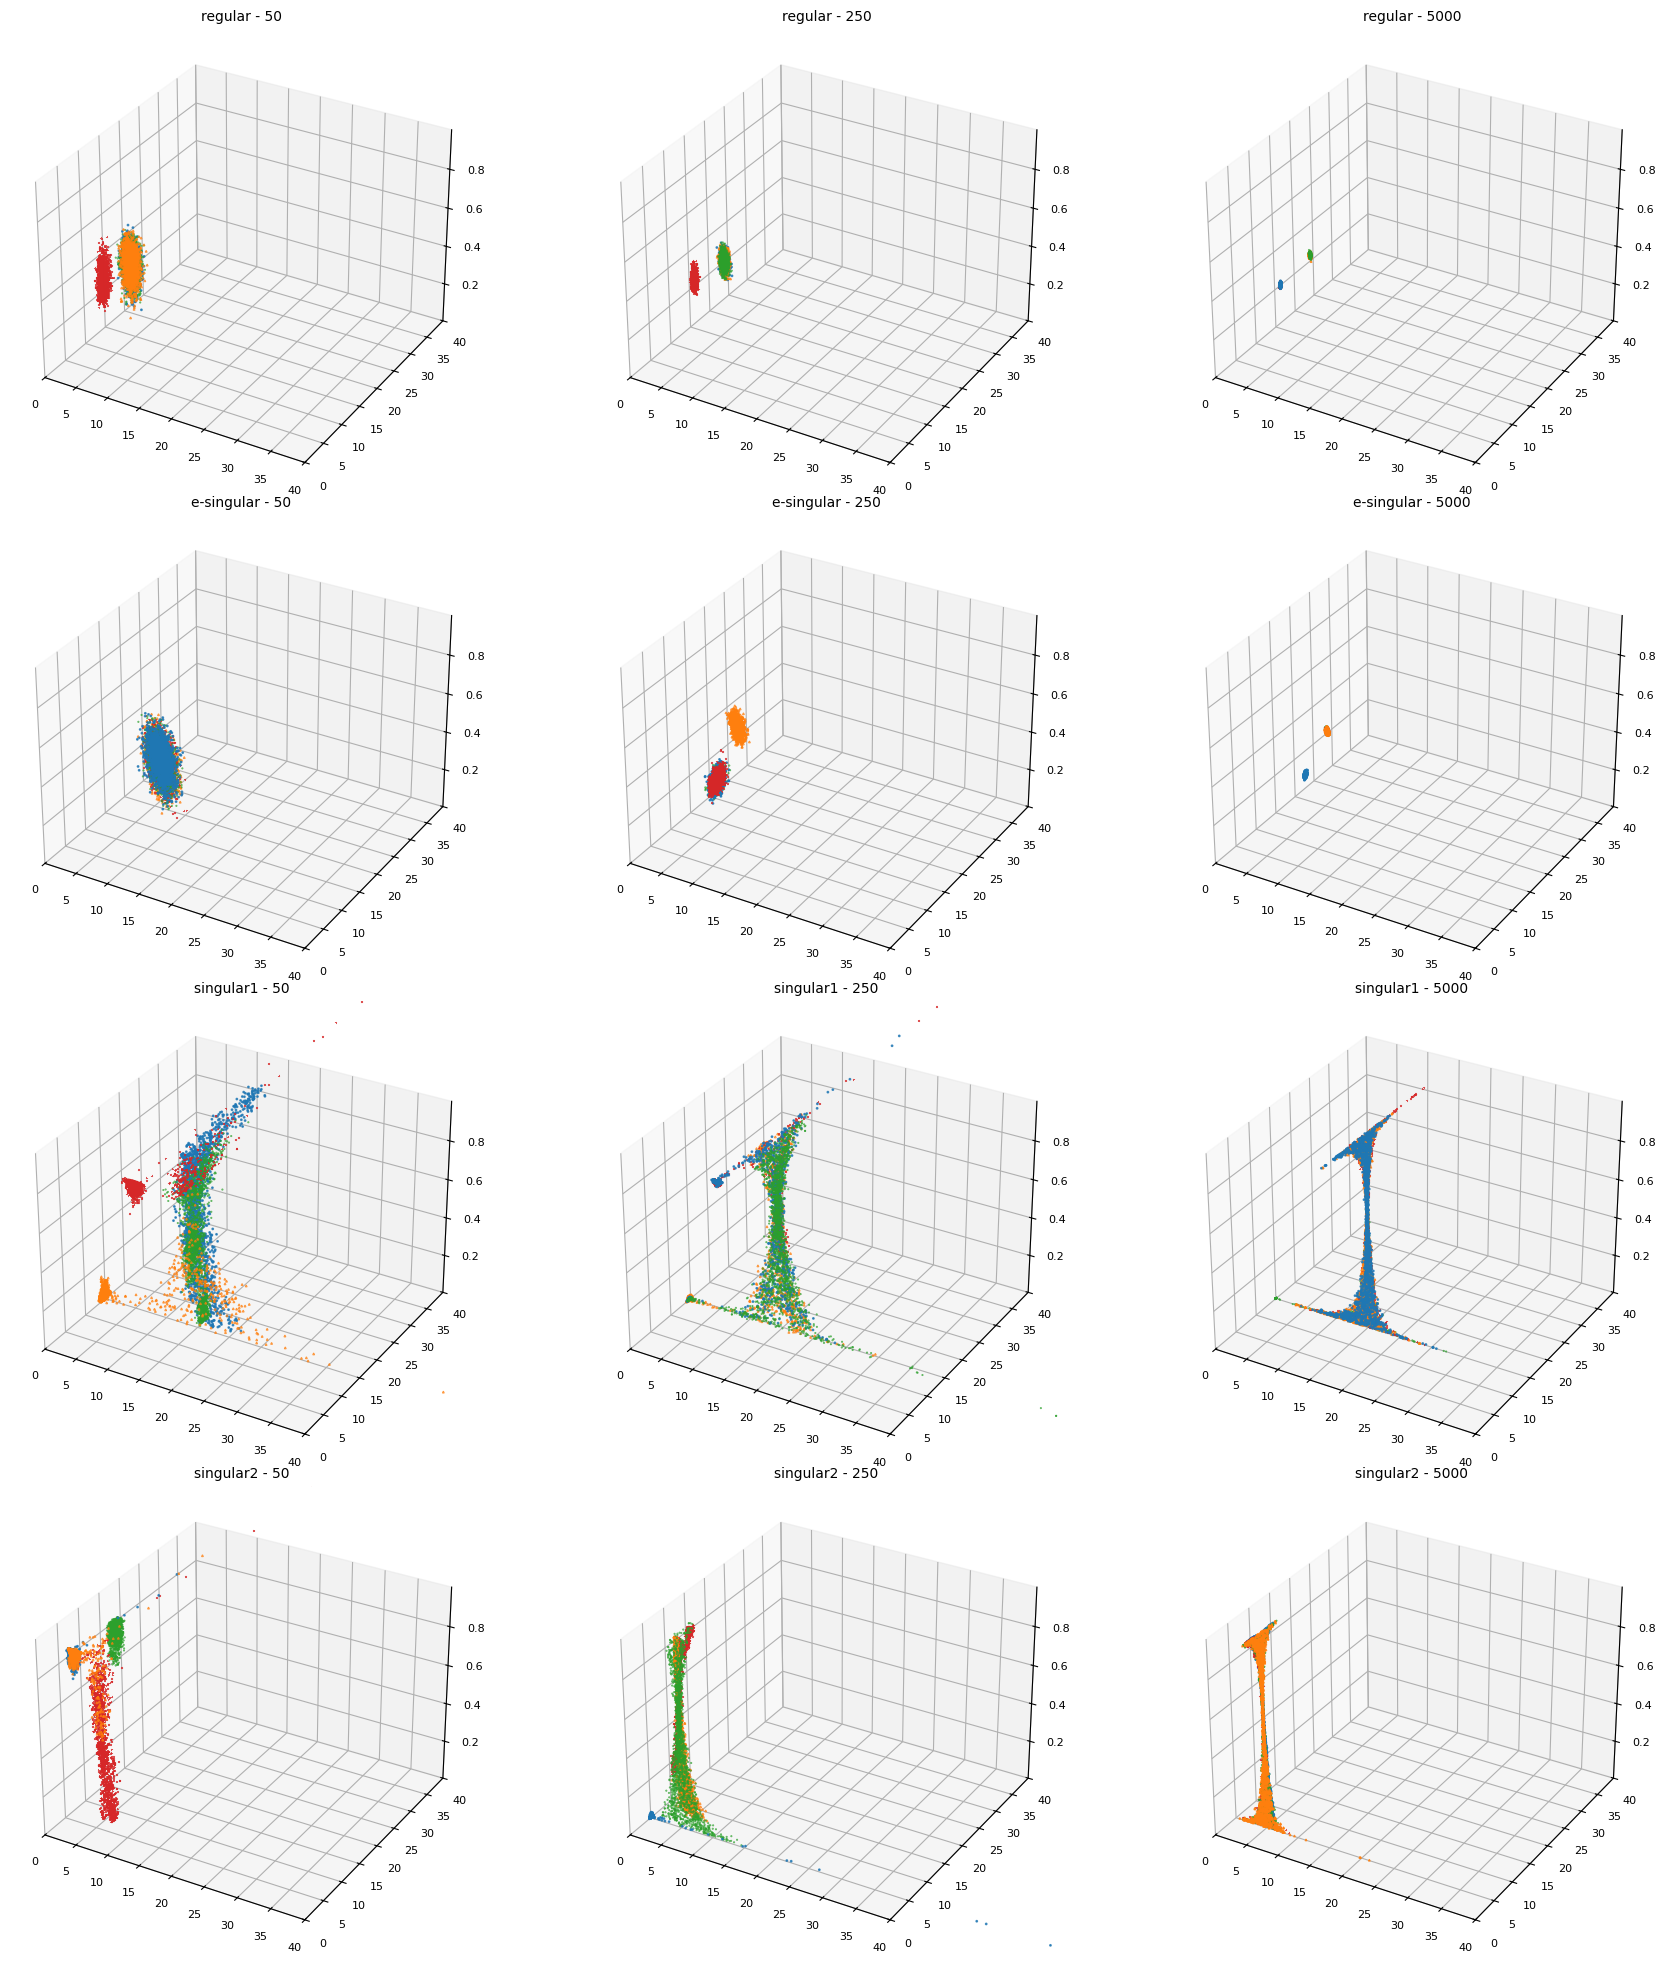

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 3, figsize=(18, 20), subplot_kw={'projection': '3d'})

# Reduce white space
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.98, top=0.98, bottom=0.02)

# First pass: collect global min/max for shared axes
all_p0, all_p1, all_w = [], [], []

for dsid, dsid_data in posterior_samples.items():
    for regime, regime_data in dsid_data.items():
        idata = posterior_samples[dsid][regime]
        for chain in range(idata.posterior.dims["chain"]):
            all_p0.extend(idata.posterior["m0"][chain, :].values)
            all_p1.extend(idata.posterior["m1"][chain, :].values)
            all_w.extend(idata.posterior["weights"][chain, :, 0].values)

p0_lim = (np.min(all_p0), np.max(all_p0))
p1_lim = (np.min(all_p1), np.max(all_p1))
w_lim = (np.min(all_w), np.max(all_w))

# Second pass: plot with shared limits
i = 0
j = 0
markers = ['o', '^', '.', '+']

for dsid, dsid_data in posterior_samples.items():
    for regime, regime_data in dsid_data.items():
        idata = posterior_samples[dsid][regime]
        n_chains = idata.posterior.dims["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["m0"][chain, :]
            p1 = idata.posterior["m1"][chain, :]
            axes[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Set shared limits
        # axes[i, j].set_xlim(p0_lim)
        # axes[i, j].set_ylim(p1_lim)
        # axes[i, j].set_zlim(w_lim)
        axes[i, j].set_xlim(0,40)
        axes[i, j].set_ylim(0,40)
        axes[i, j].set_zlim(w_lim)
        
        # Optional: reduce tick label size to save space
        axes[i, j].tick_params(labelsize=8)
        
        # Optional: add title
        axes[i, j].set_title(f'{dsid} - {regime}', fontsize=10)
        
        j += 1
    i += 1
    j = 0

plt.show()

/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_52674/212670737.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims["chain"]
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_52674/212670737.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = idata.posterior.dims["draw"]


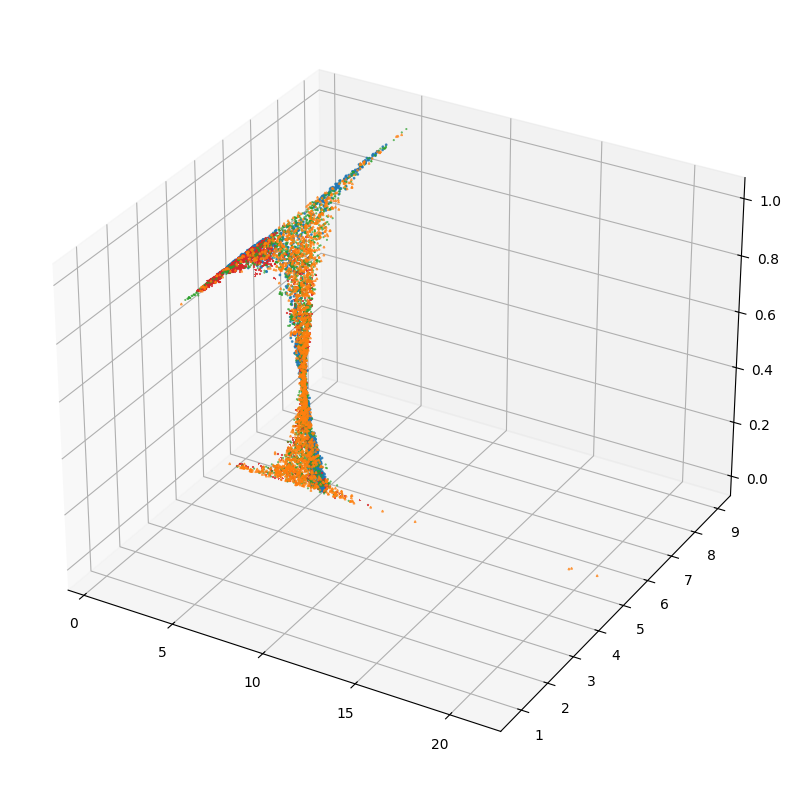

In [13]:
plot3d(dsid="singular2", regime=5000)

In [14]:
import plotly.graph_objects as go
import plotly.io as pio

def plot3dx(dsid="regular", regime=50):
  idata = posterior_samples[dsid][regime]
  fig = go.Figure()
  
  markers = ['circle', 'diamond', 'square', 'cross']
  n_chains = idata.posterior.dims["chain"]
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain, :, 0].values
    p0 = idata.posterior["m0"][chain, :].values
    p1 = idata.posterior["m1"][chain, :].values
    
    fig.add_trace(go.Scatter3d(
        x=p0, y=p1, z=w,
        mode='markers',
        marker=dict(size=1, symbol=markers[chain]),
        name=f'Chain {chain}'
    ))
  
  fig.update_layout(
      scene=dict(
          xaxis_title='m0',
          yaxis_title='m1',
          zaxis_title='w'
      )
  )
  
  # For Jupyter notebooks
  pio.renderers.default = "notebook"
  # or
  # pio.renderers.default = "iframe"
  # or for JupyterLab
  # pio.renderers.default = "jupyterlab"
  fig.update_layout(
      width=1000,
      height=800
  )
  fig.show()

In [15]:
plot3dx("singular2", 5000)

/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_52674/1286210619.py:9: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.



In [16]:
from pymc_extensions.mixture.poisson import TemperedPoissonMixture

ModuleNotFoundError: No module named 'pymc_extensions'